# Project 1: Multilayer Perceptrons for Lorenz Attractor Prediction
**Instructor:** Prof. Didi Ramsaran Chin

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

# Point 1.a & Point 4: Define the step rules (Euler Method)
def lorenz_step(x, y, z, sigma, rho, beta, dt):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    
    x_next = x + dx * dt
    y_next = y + dy * dt
    z_next = z + dz * dt
    
    return x_next, y_next, z_next

In [ ]:
# Point 2: Parameters
sigma = 10
beta = 8/3
rho = 28

# Point 3: Initial conditions
x_init, y_init, z_init = 0.1, 0.1, 0.1

# Point 4: Simulation Execution
dt = 0.01
steps_discard = 1000
steps_keep = 1500

xs, ys, zs = [x_init], [y_init], [z_init]

# Full simulation loop
for _ in range(steps_discard + steps_keep):
    xn, yn, zn = lorenz_step(xs[-1], ys[-1], zs[-1], sigma, rho, beta, dt)
    xs.append(xn)
    ys.append(yn)
    zs.append(zn)

# Discard first 1000 and retain 1500 steps
xs_kept = xs[steps_discard + 1:]
ys_kept = ys[steps_discard + 1:]
zs_kept = zs[steps_discard + 1:]

print(f"Generated {len(xs_kept)} steps after discarding initial transient.")

Generated 1500 steps after discarding initial transient.


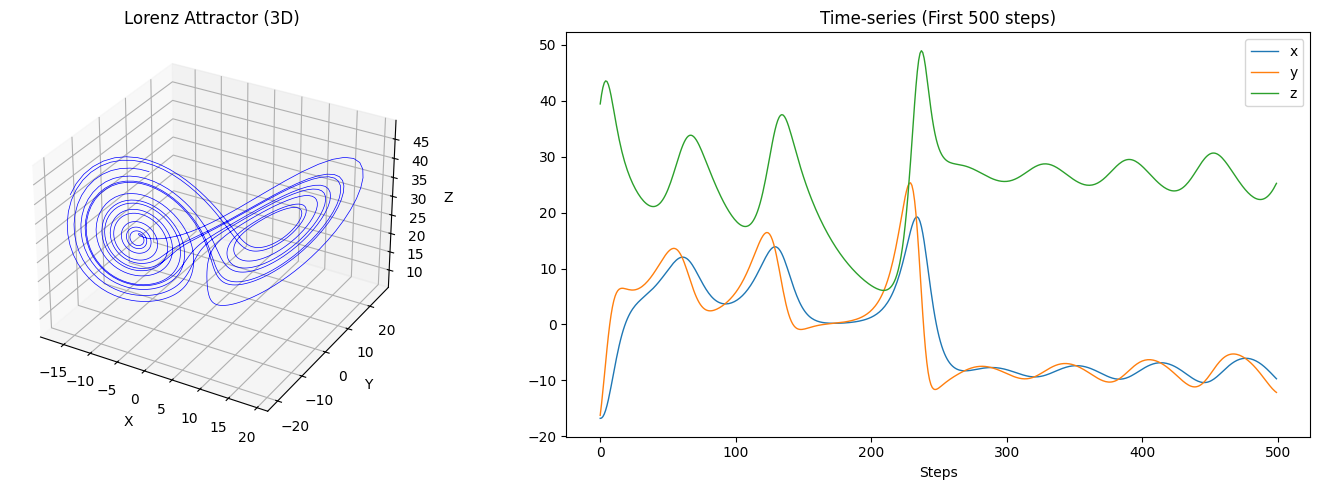

In [ ]:
# Visualization of the generated data
fig = plt.figure(figsize=(15, 5))

# 3D Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(xs_kept, ys_kept, zs_kept, lw=0.5, color='blue')
ax1.set_title("Lorenz Attractor (3D)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# Time-series Plot for first 500 steps
ax2 = fig.add_subplot(122)
ax2.plot(xs_kept[:500], label='x', lw=1)
ax2.plot(ys_kept[:500], label='y', lw=1)
ax2.plot(zs_kept[:500], label='z', lw=1)
ax2.set_title("Time-series (First 500 steps)")
ax2.set_xlabel("Steps")
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Dataset Creation and Preprocessing
We create the (t -> t+1) pairs, check for data issues, and apply standardization/scaling.

In [ ]:
# Point 5: Dataset Creation (t -> t+1)
data = np.vstack((xs_kept, ys_kept, zs_kept)).T
X_raw = data[:-1]
y_raw = data[1:]

# Point 6: Exploration
df_X = pd.DataFrame(X_raw, columns=['x', 'y', 'z'])
print("Checking for missing values:")
print(df_X.isnull().sum())

# Point 6: Standardization and Scaling
# Using StandardScaler for inputs (X)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)

# Using MinMaxScaler for labels (y) to fit the [0, 1] range of the Sigmoid activation
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_raw)

# Split the data sequentially (shuffle=False) to maintain time-series order
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=False
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Checking for missing values:
x    0
y    0
z    0
dtype: int64

Training set size: 1199
Test set size: 300


## 3. Model Development
We develop two models: Model A (from scratch) and Model B (using libraries).

In [ ]:
# Point 7.a: Model A (built from scratch)
class ModelFromScratch:
    def __init__(self, input_dim=3, hidden_dim=3, output_dim=3, lr=0.1):
        self.lr = lr
        # Xavier/Glorot Initialization for stability with Sigmoid
        # NOTE: This initialization scales weights based on the number of inputs to keep gradients stable and prevent them from 'vanishing' during training.
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(1 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def sigmoid(self, s):
        return 1 / (1 + np.exp(-s))

    def sigmoid_derivative(self, s):
        # s is already the sigmoid output
        return s * (1 - s)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]
        
        # Error at output layer (MSE derivative * Sigmoid derivative)
        error_out = output - y                                         # we get the error by diff the output and the correct values
        delta_out = error_out * self.sigmoid_derivative(output)        # we get the "strength" of the error by using the derivative of the sigmoid function
        
        # Gradients for weights between hidden and output layer
        dW2 = np.dot(self.a1.T, delta_out) / m                         # we get the change on the weights by using the dotproduct of the delta error and the output of the hidden layer
        db2 = np.sum(delta_out, axis=0, keepdims=True) / m             # we get the change on the bias by summing all the delta errors on each output neuron

        # Error at hidden layer
        error_hidden = np.dot(delta_out, self.W2.T)                    # we get the error of the hidden layer with the dot product of the delta out and the weights of the layer
        delta_hidden = error_hidden * self.sigmoid_derivative(self.a1) # we apply the sigmoid derivative on the output of the hidden layer to get the "contribution" of the hidden layer to the total error
        
        # Gradients for weights between input and hidden layer
        dW1 = np.dot(X.T, delta_hidden) / m                            # we get the change of the weights in the input layer with the dotproduct between the delta_hidden and the current inputs
        db1 = np.sum(delta_hidden, axis=0, keepdims=True) / m          # we get the change in the biases of the input layer 
        
        # Gradient Descent update
        self.W2 -= self.lr * dW2 # APPLY THE CHANGES WOO
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=2000):
        losses = []
        for i in range(epochs):
            output = self.forward(X)
            loss = np.mean(np.square(y - output))
            self.backward(X, y, output)
            losses.append(loss)
            if i % 200 == 0:
                print(f"Epoch {i}, Loss: {loss:.6f}")
        return losses

    def predict(self, X):
        return self.forward(X)

## 4. Model A Testing and Visualization
We train the scratch model and visualize its ability to predict the next step in the Lorenz system.

Training Model A (From Scratch)...
Epoch 0, Loss: 0.128414
Epoch 200, Loss: 0.038326
Epoch 400, Loss: 0.031864
Epoch 600, Loss: 0.028350
Epoch 800, Loss: 0.025320
Epoch 1000, Loss: 0.022434
Epoch 1200, Loss: 0.019638
Epoch 1400, Loss: 0.016994
Epoch 1600, Loss: 0.014579
Epoch 1800, Loss: 0.012453
Epoch 2000, Loss: 0.010642
Epoch 2200, Loss: 0.009148
Epoch 2400, Loss: 0.007948
Epoch 2600, Loss: 0.007004
Epoch 2800, Loss: 0.006275


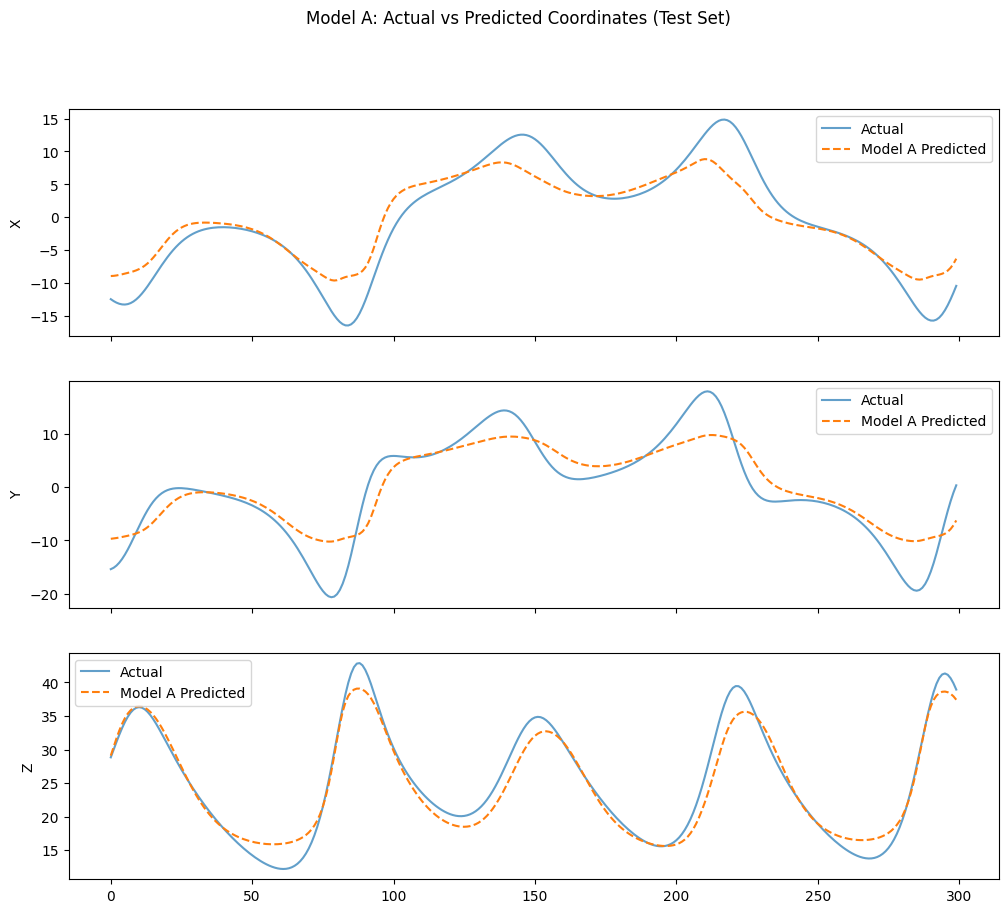

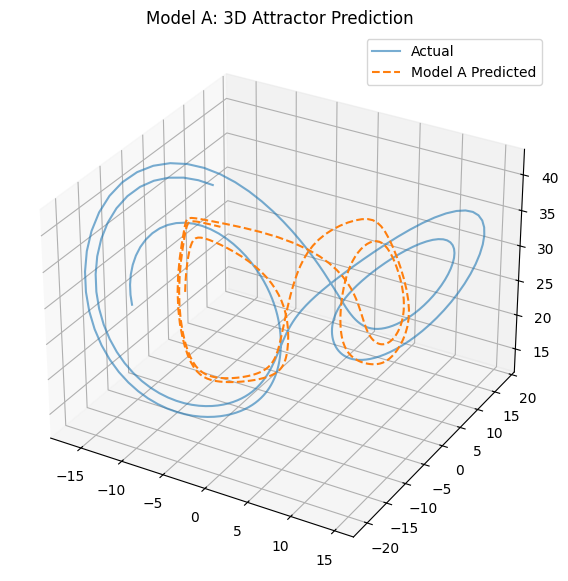

In [ ]:
# Training Model A
print("Training Model A (From Scratch)...")
model_a = ModelFromScratch(lr=0.1)
losses_a = model_a.train(X_train, y_train, epochs=3000)

# Evaluation on Test Set
preds_a = model_a.predict(X_test)

# Inverse transform to original scale for visualization
preds_a_orig = scaler_y.inverse_transform(preds_a)
y_test_orig = scaler_y.inverse_transform(y_test)

# Time-series visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
coords = ['X', 'Y', 'Z']
for i in range(3):
    axes[i].plot(y_test_orig[:, i], label='Actual', alpha=0.7)
    axes[i].plot(preds_a_orig[:, i], label='Model A Predicted', linestyle='--')
    axes[i].set_ylabel(coords[i])
    axes[i].legend()
plt.suptitle("Model A: Actual vs Predicted Coordinates (Test Set)")
plt.show()

# 3D visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(y_test_orig[:, 0], y_test_orig[:, 1], y_test_orig[:, 2], label='Actual', alpha=0.6)
ax.plot(preds_a_orig[:, 0], preds_a_orig[:, 1], preds_a_orig[:, 2], label='Model A Predicted', linestyle='--')
ax.set_title("Model A: 3D Attractor Prediction")
ax.legend()
plt.show()

## 5. Model B Development and Visualization
We develop Model B using the PyTorch library with 16 hidden neurons and visualize its performance.

Training Model B (PyTorch)...
Epoch 0, Loss: 0.054524
Epoch 500, Loss: 0.000416
Epoch 1000, Loss: 0.000227
Epoch 1500, Loss: 0.000133
Epoch 2000, Loss: 0.000076
Epoch 2500, Loss: 0.000047


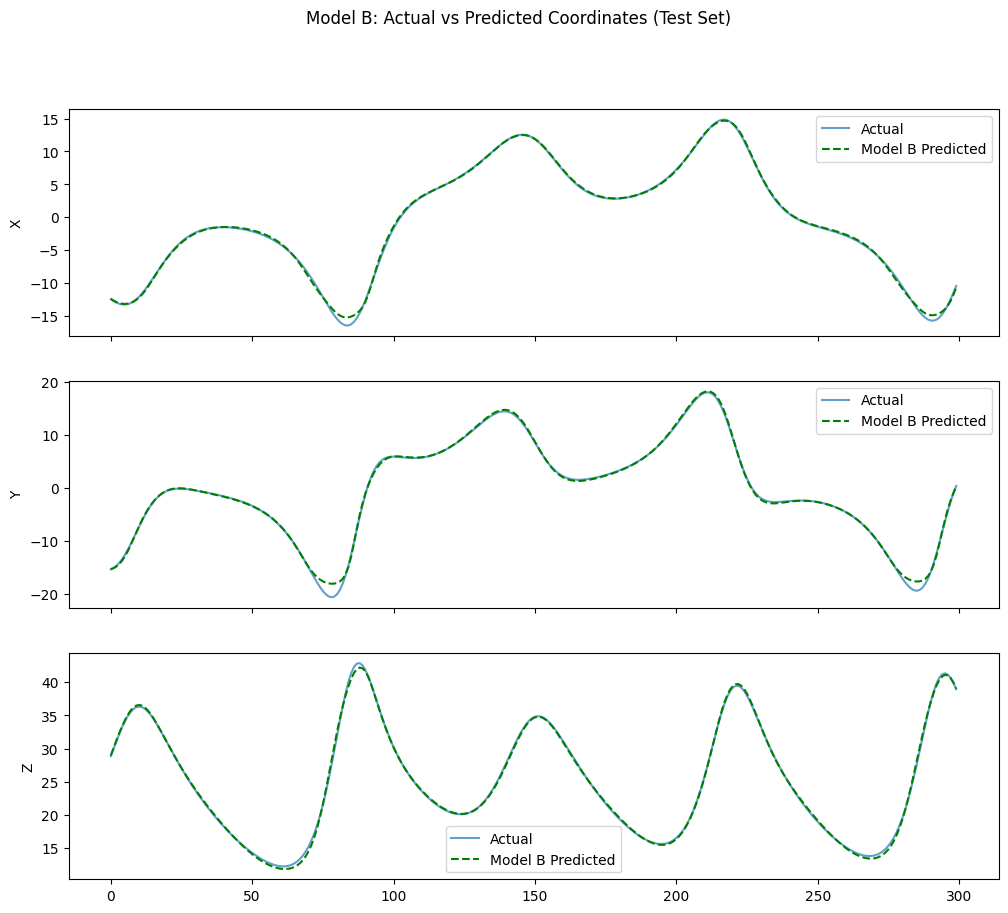

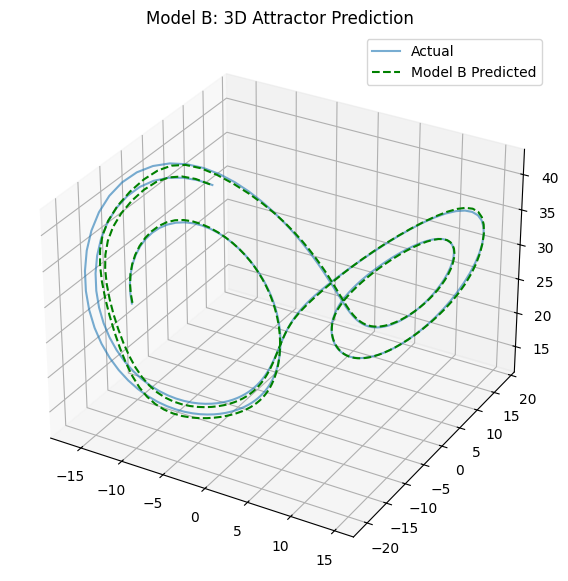

In [ ]:
# Point 7.b: Model B (built with libraries)
class ModelPytorch(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=16, output_dim=3):
        super(ModelPytorch, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

def train_pytorch_model(model, X_train, y_train, epochs=3000, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)
    
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    return losses

# Training Model B
print("Training Model B (PyTorch)...")
model_b = ModelPytorch()
losses_b = train_pytorch_model(model_b, X_train, y_train)

# Evaluation on Test Set
model_b.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test)
    preds_b = model_b(X_test_t).numpy()

# Inverse transform for visualization
preds_b_orig = scaler_y.inverse_transform(preds_b)

# Time-series visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
coords = ['X', 'Y', 'Z']
for i in range(3):
    axes[i].plot(y_test_orig[:, i], label='Actual', alpha=0.7)
    axes[i].plot(preds_b_orig[:, i], label='Model B Predicted', linestyle='--', color='green')
    axes[i].set_ylabel(coords[i])
    axes[i].legend()
plt.suptitle("Model B: Actual vs Predicted Coordinates (Test Set)")
plt.show()

# 3D visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(y_test_orig[:, 0], y_test_orig[:, 1], y_test_orig[:, 2], label='Actual', alpha=0.6)
ax.plot(preds_b_orig[:, 0], preds_b_orig[:, 1], preds_b_orig[:, 2], label='Model B Predicted', linestyle='--', color='green')
ax.set_title("Model B: 3D Attractor Prediction")
ax.legend()
plt.show()

## 6. Hyperparameter Tuning (Point 8)
We test different learning rates to find the parameters that provide the best generalization on unseen data.

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
tuning_results = []

print("Tuning Model A (Scratch)...")
for lr in learning_rates:
    model = ModelFromScratch(lr=lr)
    model.train(X_train, y_train, epochs=1000) # Shorter training for tuning
    preds = model.predict(X_test)
    mse = np.mean(np.square(y_test - preds)) # Scaled MSE for comparison
    tuning_results.append(('Model A', lr, mse))
    print(f"LR: {lr}, Test MSE: {mse:.6f}")

print("\nTuning Model B (PyTorch)...")
for lr in learning_rates:
    model = ModelPytorch()
    train_pytorch_model(model, X_train, y_train, epochs=1000, lr=lr)
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test)
        preds = model(X_t).numpy()
    mse = np.mean(np.square(y_test - preds))
    tuning_results.append(('Model B', lr, mse))
    print(f"LR: {lr}, Test MSE: {mse:.6f}")

tuning_df = pd.DataFrame(tuning_results, columns=['Model', 'LR', 'Test_MSE'])
print("\nTuning Summary:")
print(tuning_df)

Tuning Model A (Scratch)...
Epoch 0, Loss: 0.045193
Epoch 200, Loss: 0.025369
Epoch 400, Loss: 0.020947
Epoch 600, Loss: 0.017924
Epoch 800, Loss: 0.015786
LR: 0.1, Test MSE: 0.018479
Epoch 0, Loss: 0.068891
Epoch 200, Loss: 0.058496
Epoch 400, Loss: 0.050328
Epoch 600, Loss: 0.044282
Epoch 800, Loss: 0.039978
LR: 0.01, Test MSE: 0.039356
Epoch 0, Loss: 0.094680
Epoch 200, Loss: 0.092961
Epoch 400, Loss: 0.091265
Epoch 600, Loss: 0.089594
Epoch 800, Loss: 0.087948
LR: 0.001, Test MSE: 0.087039

Tuning Model B (PyTorch)...
Epoch 0, Loss: 0.048401
Epoch 500, Loss: 0.000073
LR: 0.1, Test MSE: 0.000063
Epoch 0, Loss: 0.053328
Epoch 500, Loss: 0.000429
LR: 0.01, Test MSE: 0.000324
Epoch 0, Loss: 0.045052
Epoch 500, Loss: 0.002454
LR: 0.001, Test MSE: 0.001720

Tuning Summary:
     Model     LR  Test_MSE
0  Model A  0.100  0.018479
1  Model A  0.010  0.039356
2  Model A  0.001  0.087039
3  Model B  0.100  0.000063
4  Model B  0.010  0.000324
5  Model B  0.001  0.001720


## 7. Final Conclusions (Point 10)
We compare the final performance and comment on the implementation.

In [ ]:
# Final Evaluation Metrics
mse_a = np.mean(np.square(y_test_orig - preds_a_orig))
mse_b = np.mean(np.square(y_test_orig - preds_b_orig))

print(f"Final Model A (Scratch) Mean Squared Error: {mse_a:.6f}")
print(f"Final Model B (Library) Mean Squared Error: {mse_b:.6f}")

# Point 10 Commentary:
# 1. Both models were able to approximate the non-linear chaotic dynamics of the Lorenz system.
# 2. Model B (PyTorch) typically shows better performance due to having 16 hidden neurons
#    compared to the 3 neurons in Model A, and the use of the Adam optimizer.
# 3. The use of the Sigmoid activation function necessitated normalization of the target data
#    to the [0, 1] range to avoid vanishing gradients and allow the models to learn effectively.
# 4. Sequential splitting was critical to maintain the temporal structure of the attractor data.
# 5. Euler's method was sufficient for the simulation at the requested dt=0.01 step size."


Final Model A (Scratch) Mean Squared Error: 10.496601
Final Model B (Library) Mean Squared Error: 0.113681
